# Exercise project 1


### <i>Dataset evaluation report </i>

<i>Student name</i>

---

### Summary

|Topic               |Description               |
|--------------------|--------------------------|
|Dataset Name:       | Red wine quality dataset                         |
|Dataset Link:       | https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009                         | 
|Target Variable:    | quality (3 - 8)                         | 
|Type of Dataset:    | Classification

<br>



---


## Overview

<br>
<br>

##### <b> <u>Step 1a</u>: Inspect the datatypes for each column </b> 

<i>
<strong style='color:orange ; background-color:black;'>Fix these before continuing below.</strong>


Some visuals require numeric/datetime columns (heatmaps, matrices, etc). Most common problem is date-columns being in string/object -format => change to DateTime -objects.
</i>

<i>Easiest option is probably to use pandas' dtypes-feature.</i>


<br><br>
<br>

##### <b> <u>Step 1b</u>: Inspect the shape of the dataset (the number of rows and columns.) </b> 

<i>


How many rows and columns are in your dataset? 

Are you expecting any issues if you were to train a model with this amount of rows/columns?

Justify your answer. Provide visuals if needed.

<br>

<u><b>Hint:</b></u> ydata-profiling, pandas.shape()

</i>

<br>

<hr>

12 variables and ~1600 rows of data.

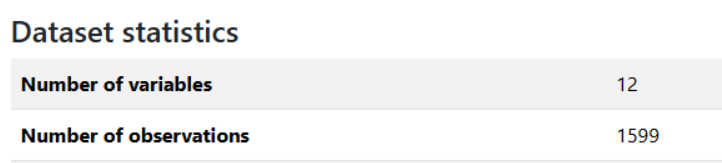

Datatypes are all good, no need to change anything here.

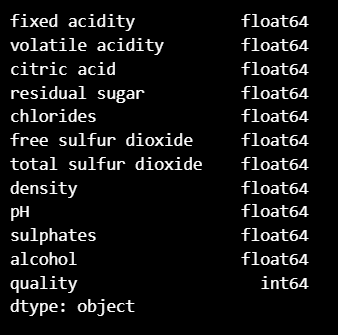

<hr>

##### <b> <u>Step 1c</u>: Inspect NaN values, duplicates, zeroes, invalid/nonsensical/problematic values </b> 

<i>
How many missing values are there? 
<br>

How many duplicate values are there? 

Are there any abnormal amounts of zeroes?

Are there any values which don't make sense or don't belong there?

Please explain how each of these values in your dataset might or might not be problematic.

<br>

<u><b>Hint:</b></u> ydata-profiling, pandas


</i>


<hr>

Unfortunately, 220 duplicate rows in an already fairly small dataset (~1600 rows).

No missing values in the dataset.

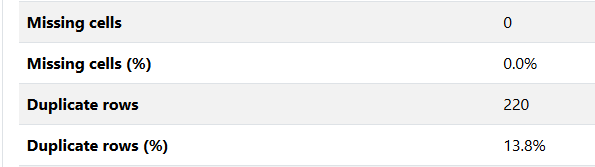

Values look normal for the most part, but citric acid is sometimes 0. 

After quick check-up with generative AI (Google's integrated AI assistant), it seems it's possible for red wine to have 0 amount of citric acid.

<hr>

##### <b> <u>Step 1d</u>: Are there any alerts recommendations?</b> 

<i>
When you used a big-picture tool(s), what kind of alerts did it give you? Were they valid concerns?

<br>

Justify. If possible, please show a visual.

<br>

<u><b>Hint:</b></u> ydata-profiling, SweetViz, AutoViz, dataprep etc.
</i>



<hr>

Multiple high correlations have been mentioned, need to check these more closely in later stages in this report.

Also, the duplicates are mentioned again.

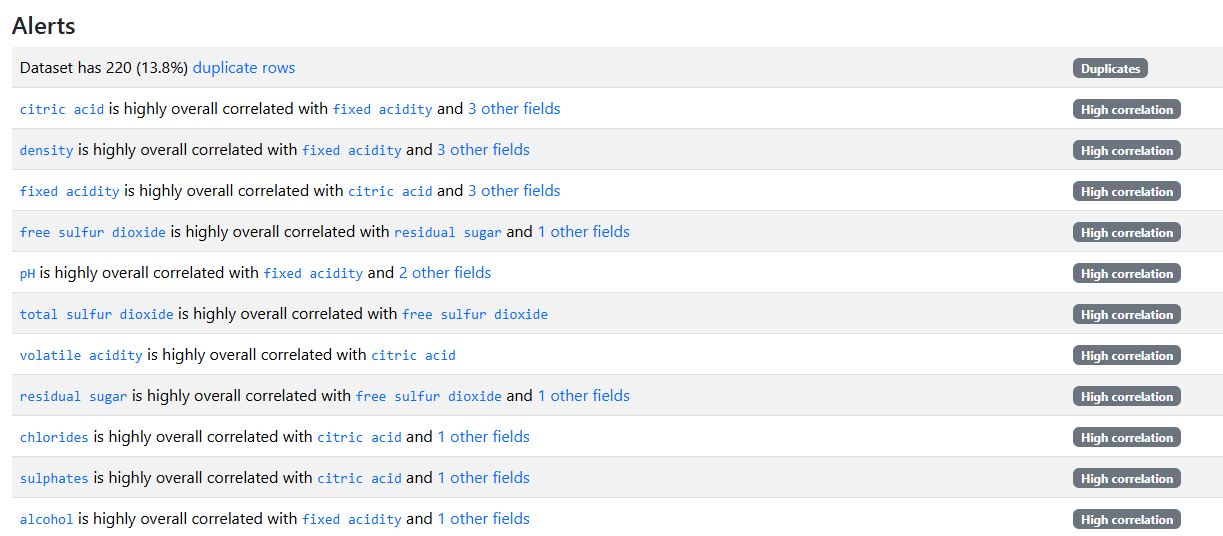

Some skewness implied in residual sugar, chlorides and sulphates. Citric acid has some zeroes present.

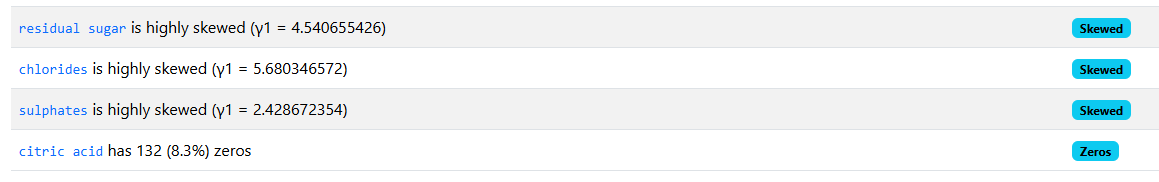

AutoViz and the custom alert code produced mostly outlier detection. Since outliers tend to be everywhere, this might imply overlapping in data since the target is ordinal (3-8).

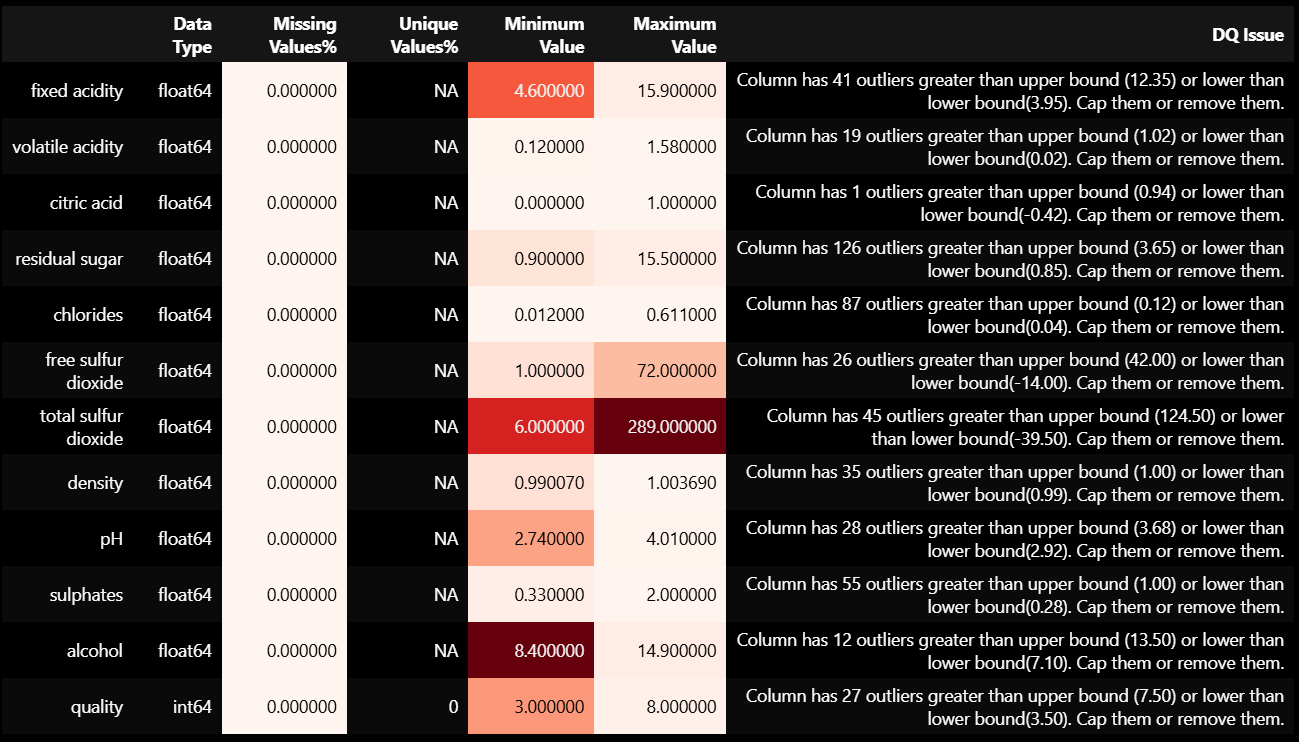

---

## Distribution, outliers, imbalances

<br>
<br>

##### <b> <u>Step 2a</u>: Distributions & imbalances</b> 

<i>
Inspect the distribution for the target variable and its features. 
<br>

Which columns may have distributions which are problematic for machine learning? 
<br>

For each problematic column, describe what kind of problems they exhibit (for example: left-skewed, right-skewed, high kurtosis, low kurtosis).

Do you expect this will be an issue when training ML models? Justify your answers. Please introduce visuals.

 <br>

<u>OPTIONAL:</u> 

Q-Q plots. Another way to visualize distributions is using Q-Q plots. 

These are particularly good for identifying thin/thick-tailed distributions and are an alternative to histograms. 

Do these phenomena exist in your dataset?  

<br>

<u><b>Hint:</b></u> ydata, SweetViz, Dtale, pandas…



</i>
<br>

<hr>

The target variable (quality) seems to follow a rough normal distribution, but with some high kurtosis.

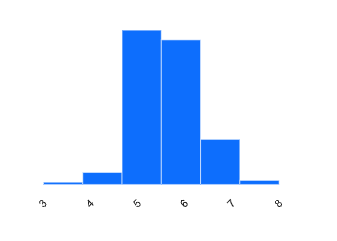

The more problematic part here are the underrepresented (**severe imbalance**) amounts of low and high quality levels. This will be problematic in ML context, since there's not enough data for quality levels 3-4 and 7-8. Some data synthetization might be in order later for this dataset.

Fixed acidity has a skewed distribution with some interesting spikes throughout the distribution.

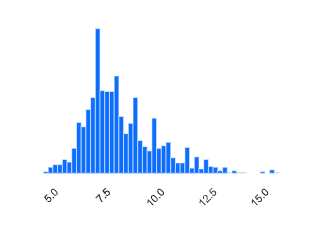

Volatile acidity is skewed, but is somewhat closer to normal distribution. There's a weird lower part around the 0.5 value mark though.

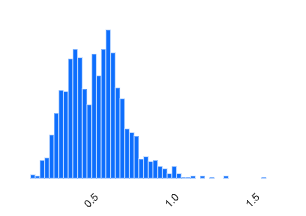

Citric acid seems almost like uniform distribution, but many values are 0 (which should be plausible in red wines).

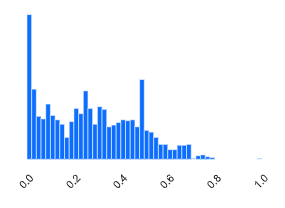

Residual sugar stacks heavily towards the lower values (probably makes sense, red wines are not inherently sweet).

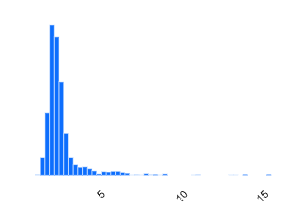

Chlorides stack heavily towards the lowe values, with some rare outliers in the high end.

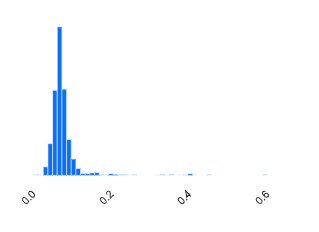

Free sulfur dioxide, almost like a skewed normal distribution, but lots of variation/spikes in the distirbution. Also outliers seem to be present in the high end.

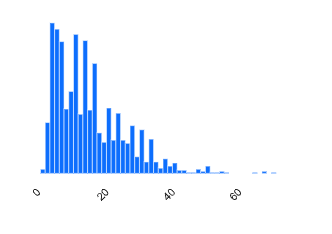

Total sulfur dioxide seems more stable, skewed again but no major spikes in the distribution.

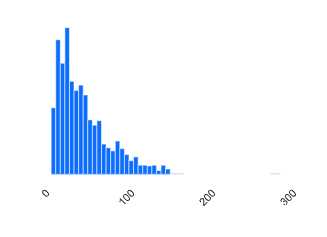

Density is fairly close to a normal distribution.

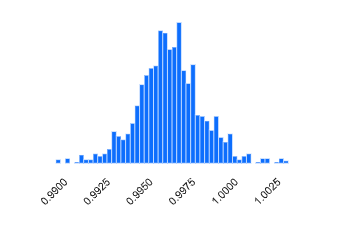

Q-Q-plot also implies that density is close to normal distribution:

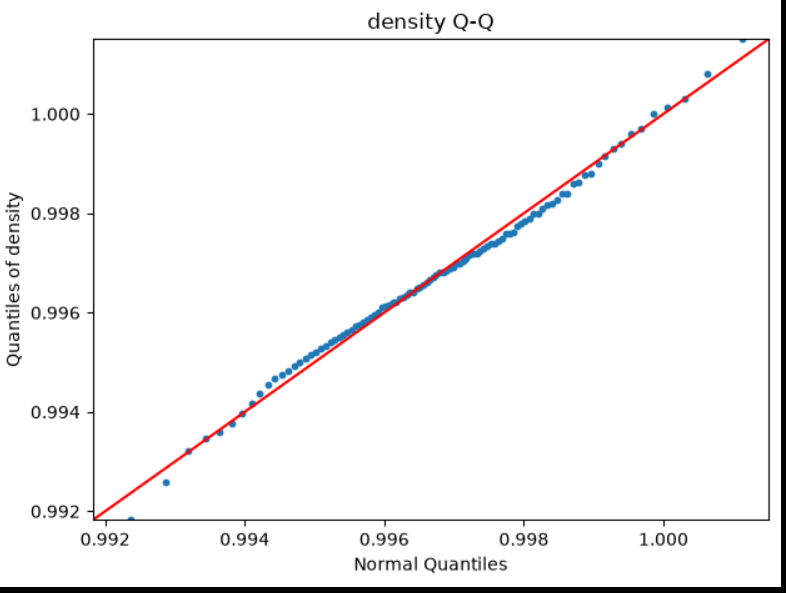

pH is roughly a normal distribution, with some spikes around the mean.

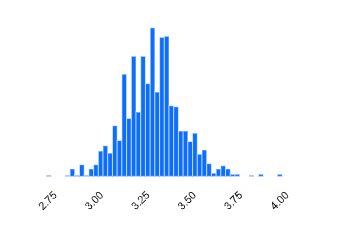

Sulphates is skewed, but otherwise fairly close to normal distribution.

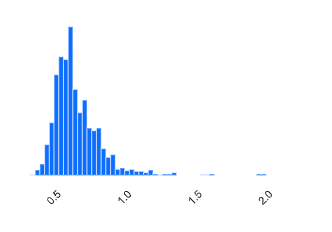

Alcohol seems to be a bit all over the place, kind of like between a skewed normal distribution with a hint of uniform. Some outliers also present in the high end.

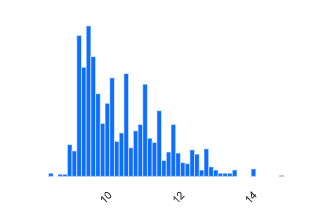

<hr>

##### <b> <u>Step 2b</u>: Multicollinearity & redundancy </b> 

<i>
Some columns may prove to be redundant to others -- Or even worse, they give away the answer entirely.
    <br>

Are there any columns which are redundant and/or suggest high multi-collinearity? 

Which tool(s)/test(s) have you performed to come to this conclusion? 

Justify your answer and, if possible, produce your results as an image below.

<br>

<u><b>Hint:</b></u> VIF test, Correlation Matrix, Phik-matrix, RFE etc.

</i>
<br>

<hr>

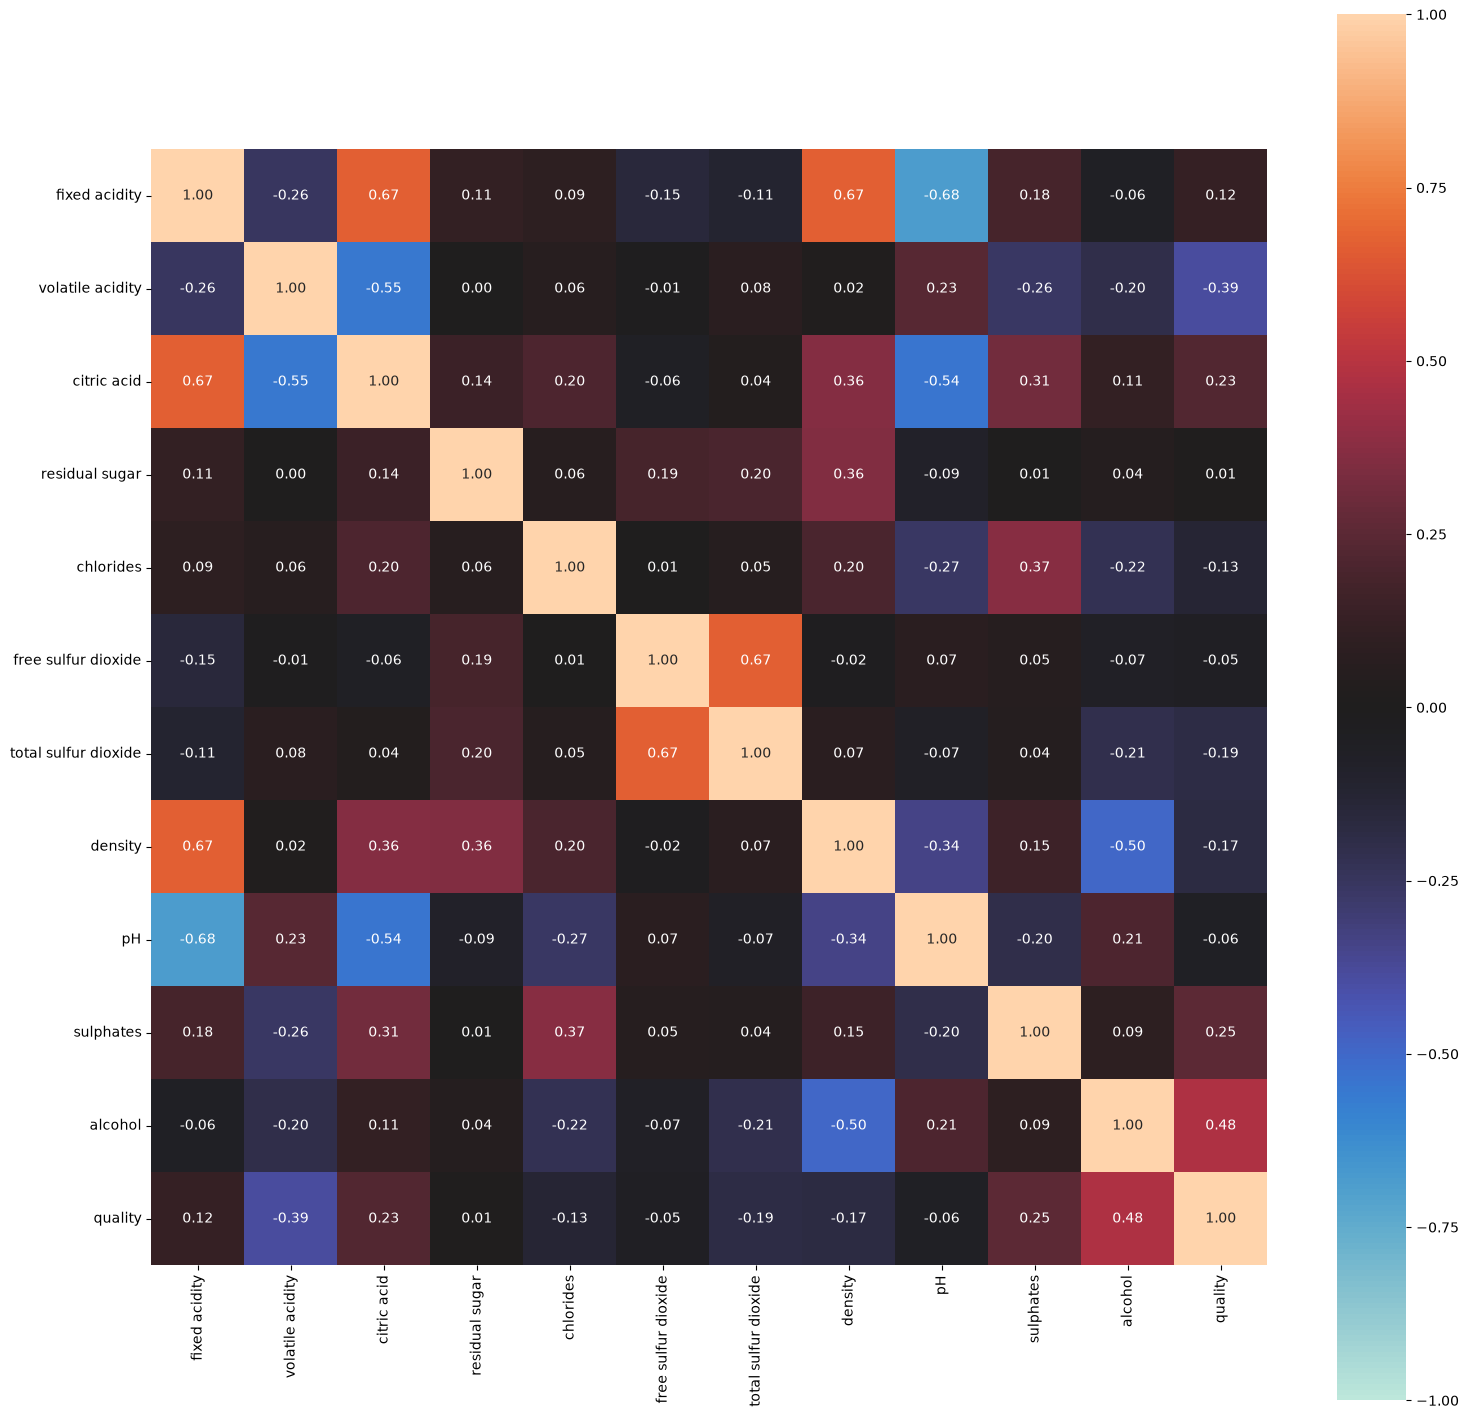

The following correlations could imply a potential redundancy (based on picture above):
- fixed acidity vs density
- fixed acidity vs pH
- fixed acidity vs citric acid
- pH vs citric acid
- volatile acidity vs citric acid
- free sulfur dioxide vs total sulfur dioxide (this is very likely to be redundancy)
- density vs alcohol

RFE marks free sulfur dioxide, fixed acidity and citric acid as least important variables in the dataset.

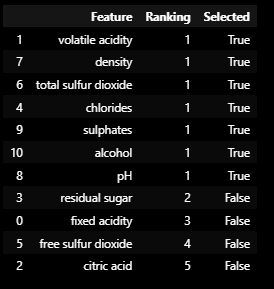

Mutual Information marks down total sulfur dioxide low, but for some reason citric acid and fixed acidity are higher. Then again volatile acidity is the lowest which should be a fairly important variable when considering red wine quality.

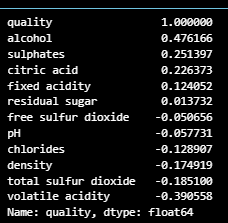

Then again, VIF doesn't really rise very high with the dataset, marking down fixed acidity, density and pH as highest values. Citric acid is somewhere in the between.

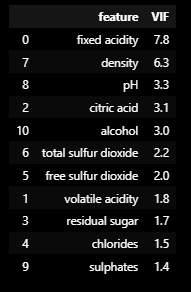

No clear redundancy is present. However, one of the sulfur dioxides might be redundant. Fixed acidity also seems redundant due to how often it's mentioned above.

<hr>

##### <b> <u>Step 2c</u>: High cardinality</b> 

<i>
Inspect each categorical column for high-cardinality (high percentage of unique values in the dataset). 

<br>

Which columns, if any, contain an unusual or problematic amount of unique values?  Which tool(s) or method(s) did you use to come to this conclusion? 

Justify your answer and, if possible, produce the output as a visual.

<br>

<u><b>Hint:</b></u> Big picture tool like ydata-profiling, pd.value_counts()

</i>
<br>

<hr>

No categorical variables in this dataset, so no high cardinality either present. 

Target variable has 6 different options, which should be manageable.



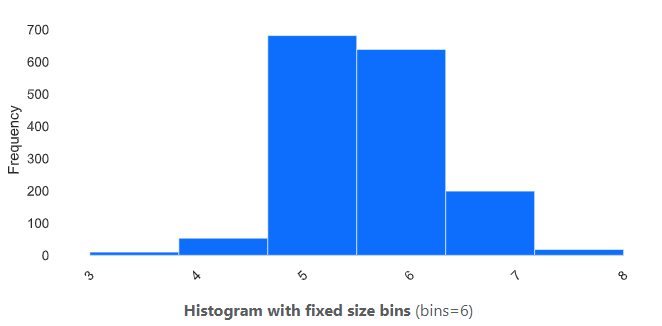

---

## Overlapping, noise, and correlation/associations

<br>
<br>

##### <b> <u>Step 3a</u>: Major trends</b> 

<i>
After inspecting the trends between your target variable and its features -- Are you noticing anything interesting?
<br>

 Any surprising positive or negative trends?
 
  Any evidence of noise (jittering)?
  
Are your interesting columns linear or non-linear?

Is there anything that 'breaks the rules' of the trend?
 
Please provide visuals of which major trends you found interesting and worthy mentioning.

Hypothesize and, if necessary, research online why this irregular trend occurs.

Also, provide which tool(s) you have used to inspect this aspect of your dataset.

<br>

<u><b>Hint:</b></u> regression plots/scatterplot/pairplot, correlations/phik-matrix/associations, feature importance tools ...

</i>
<br>

<hr>

The quality of the wine seems to determined largely by alcohol (strongest predictor potentially). However, there's a dip in quality level 5 with numerous outliers. 

Based on my experience (and discussions with professionals in this field), this is probably the average type of fine common in supermarkets etc., where wild experimentation with red wine profiles is common.

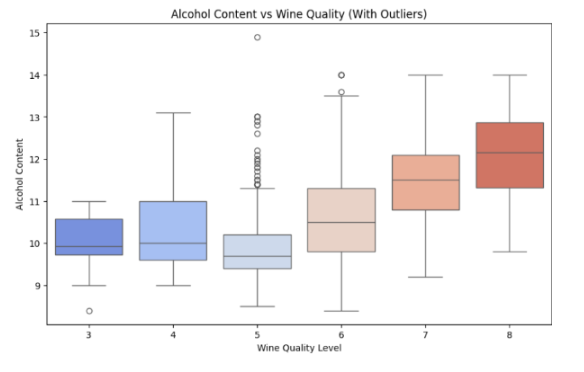

Volatile acidity together with alcohol seem to largely describe a loose trend for the quality. Low acidity + high alcohol content => high quality.

However, numerous exceptions/overlap is present in this dataset.

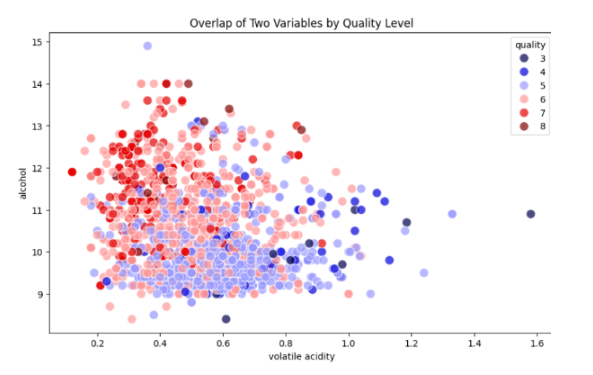

Volatile acidity has a much more clear trend towards the quality. Low acidity => higher quality (usually). The outliers in quality level 5 are still present.

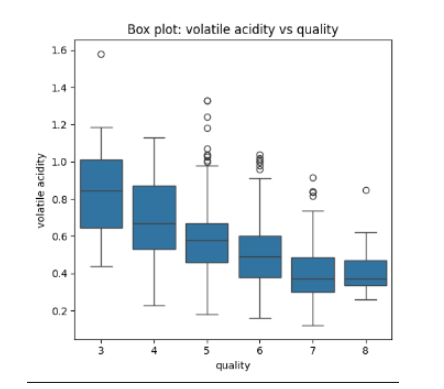

Sulphates also seem to explain quality here. It seems higher sulphates with lower acidity seem to increase quality.

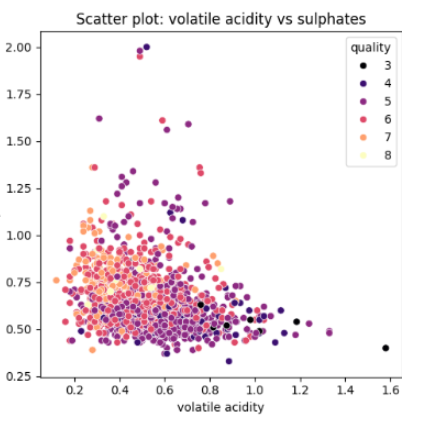

Sulphates vs alcohol, mild connection too. Higher alcohol content + slightly higher sulphates => often higher quality. However, many outliers are present on the high sulphate side.

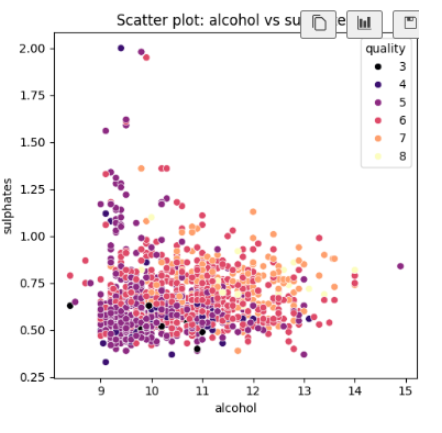

Decision tree marks down alcohol content as the single most important predictor for red wine quality. After that, total sulfur dioxide, residual sugar and especailly sulphates seem dominant. Volatile acidity is surprisingly hidden in the dataset.

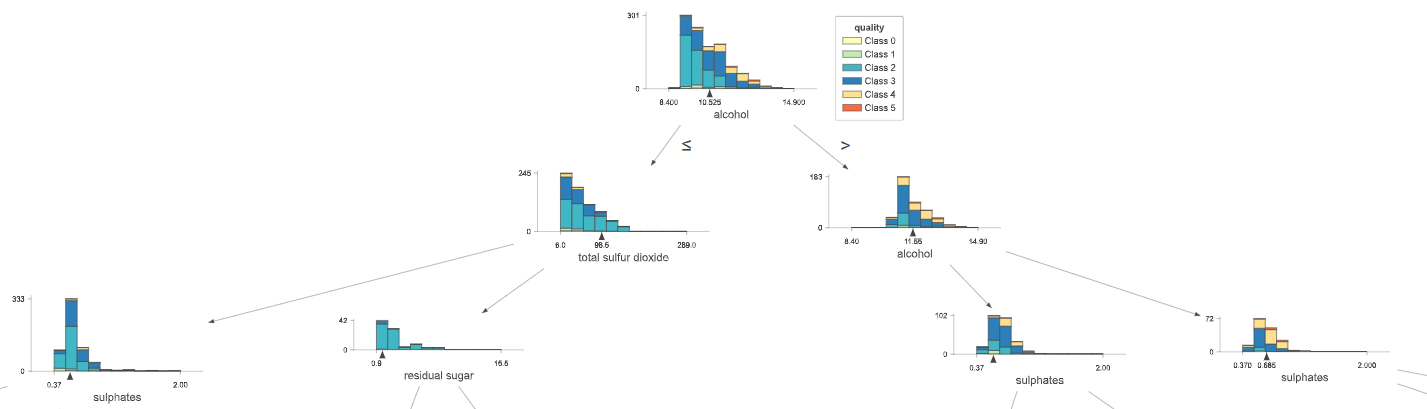

<hr>

##### <b> <u>Step 3b</u>: Overlapping Data</b> 

<i>
Does any overlapping exist between the features and your target variable?
<br>

Do you expect this to be an issue if you were to train a model with this data?

Justify your answer and, if reasonably possible, provide visuals.

Also, provide which tool(s) you have used to inspect this aspect of your dataset.

<br>

<u><b>Hint:</b></u> seaborn box-/scatterplots
</i>
<br>

<hr>

This is probably the greatest issue in this dataset, absolutely devastating overlap is present even in the two highest predictor support variables, alcohol and volatile acidity.

There is a rough trend => high alcohol + low acidity => higher quality. BUT! There are numerous overlapping cases especially in the middle parts. THe overlapping parts are mostly quality levels 5 and 6. We can already see here that these quality levels will be trouble to an ML model later.

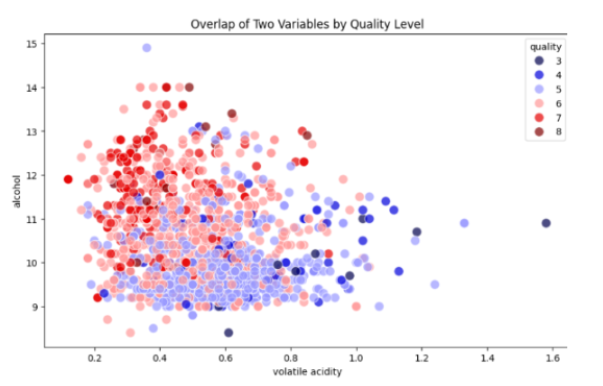

See above section also for more overlapping cases in other variables. It truly seems the quality levels 5-6 are very hazy in their differences.

We have to remember, that the original dataset has probably been labeled by an expert panel of red wine tasters, so there's a level of subjectivity in the dataset.

Then again, with machine learning, we usually aim to automate a human evaluation process.

<hr>

##### <b> <u>Step 3c</u>: Outliers & noise</b> 

<i>
Inspect each categorical column for potential outliers and noise. 

<br>

<u>For each column with noise:</u>

In which columns are you detecting noise? Which tool(s) or method(s) did you use to find this?


<u>For each column with outliers:</u>

Are you seeing many outliers in your columns? How extreme (in your opinion) are the outliers? How problematic do you expect this to be if these outliers remained in the dataset? Which tool(s) or method(s) did you use to find this?


<u><b>Hint:</b></u> Isolation Forest, IQR, z-score, Elliptic Envelope, MAD...




</i>
<br>

<hr>

Isolation forest used here. It seems even isolation forest marks down outliers throughout the dataset. This is probably due to the overlap and "uncommon combinations/value ranges" for certain quality levels. Outliers found this way exist in all quality levels, it seems. I would have expected to have most of them in quality levels 5-6.

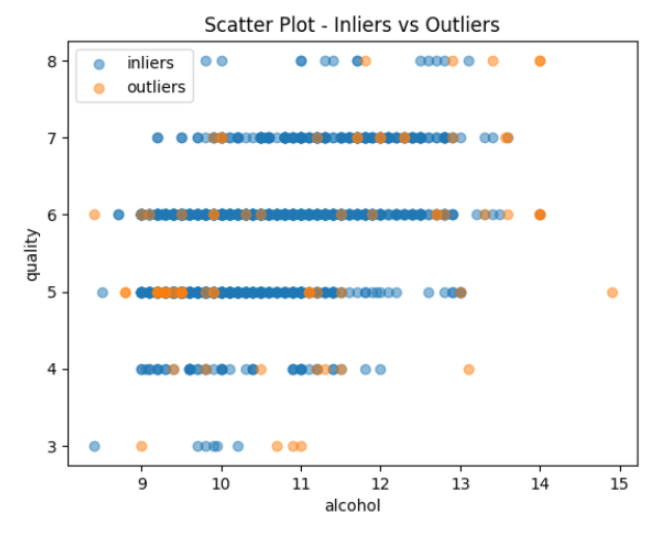

Elliptic envelope seems to be still concentrating more on the inside of the dataset for outliers.

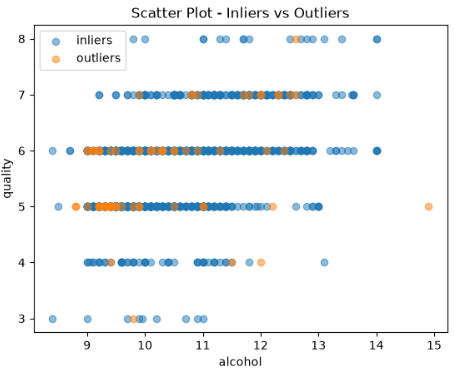

MAD seems to mark down high values as noise:

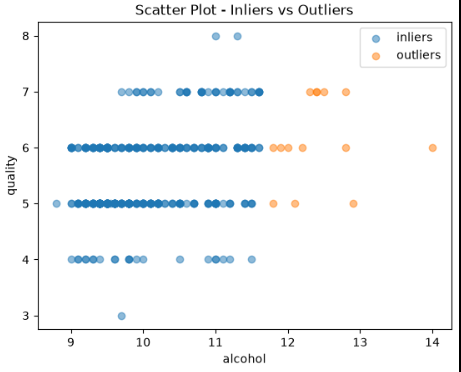

But for volatile acidity, the noise are marked down within the dataset. Result is similar for sulphates as well. This is probably due to the severe overlap in the data:

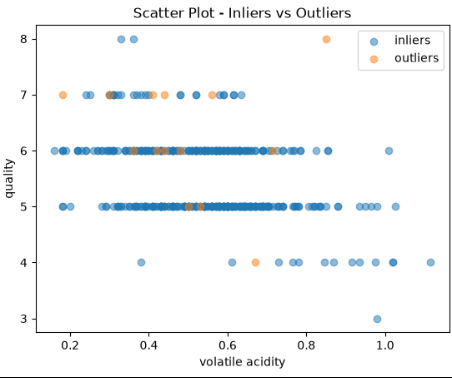

zscore and IQR are not very useful, since they only mark lowest quality as outliers (due to huge issue with the target variable balance)

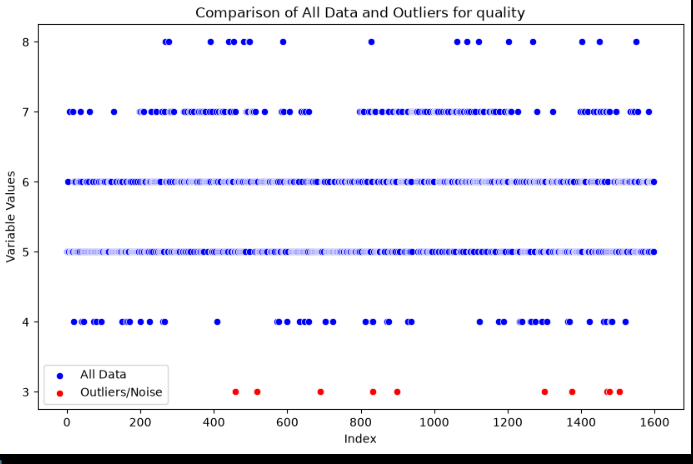

<hr>

##### <b> <u>Step 3d</u>: Correlations & associations</b> 

<i>
Inspect the Phi-K and Correlations matrix.

<br>

What kind of linear relationships are you detecting that correlate with your target variable?
 
What kind of non-linear relationships are you detecting that associate with your target variable?

Do you suspect any noise and/or multi-collinearity from these results?

Are there any other interesting things you found?

Justify your answer and provide visuals of the output of both the phi-k and correlation matrix.

<br>

<u><b>Hint:</b></u> Phik/pd.corr + heatmap, or ydata with phik-support, SweetViz -associations, Dython ...


</i>
<br>

<hr>

Correlations/associations (Dython):

As expected, alcohol, volatile acidity (negative connection) and sulphates seem to be important here. Suprisingly, also citric acid seems to be important. 

Residual sugar, free sulfur dioxide and pH seem to be fairly disconnected from the target variable.

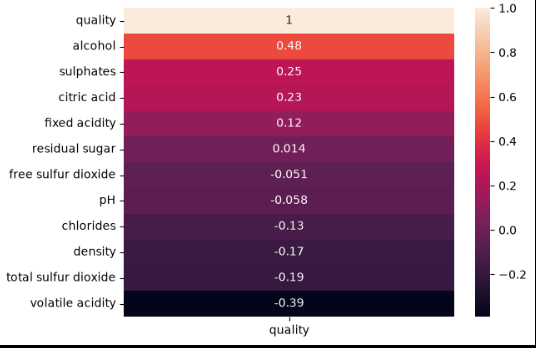

Other interesting notes in the matrix below:
- Citric acid seems to be connected to volatile acidity
- Alcohol seems to be connected to density
- sulphates are connected slightly to multiple variables: volatile acidity, citric acid and chlorides

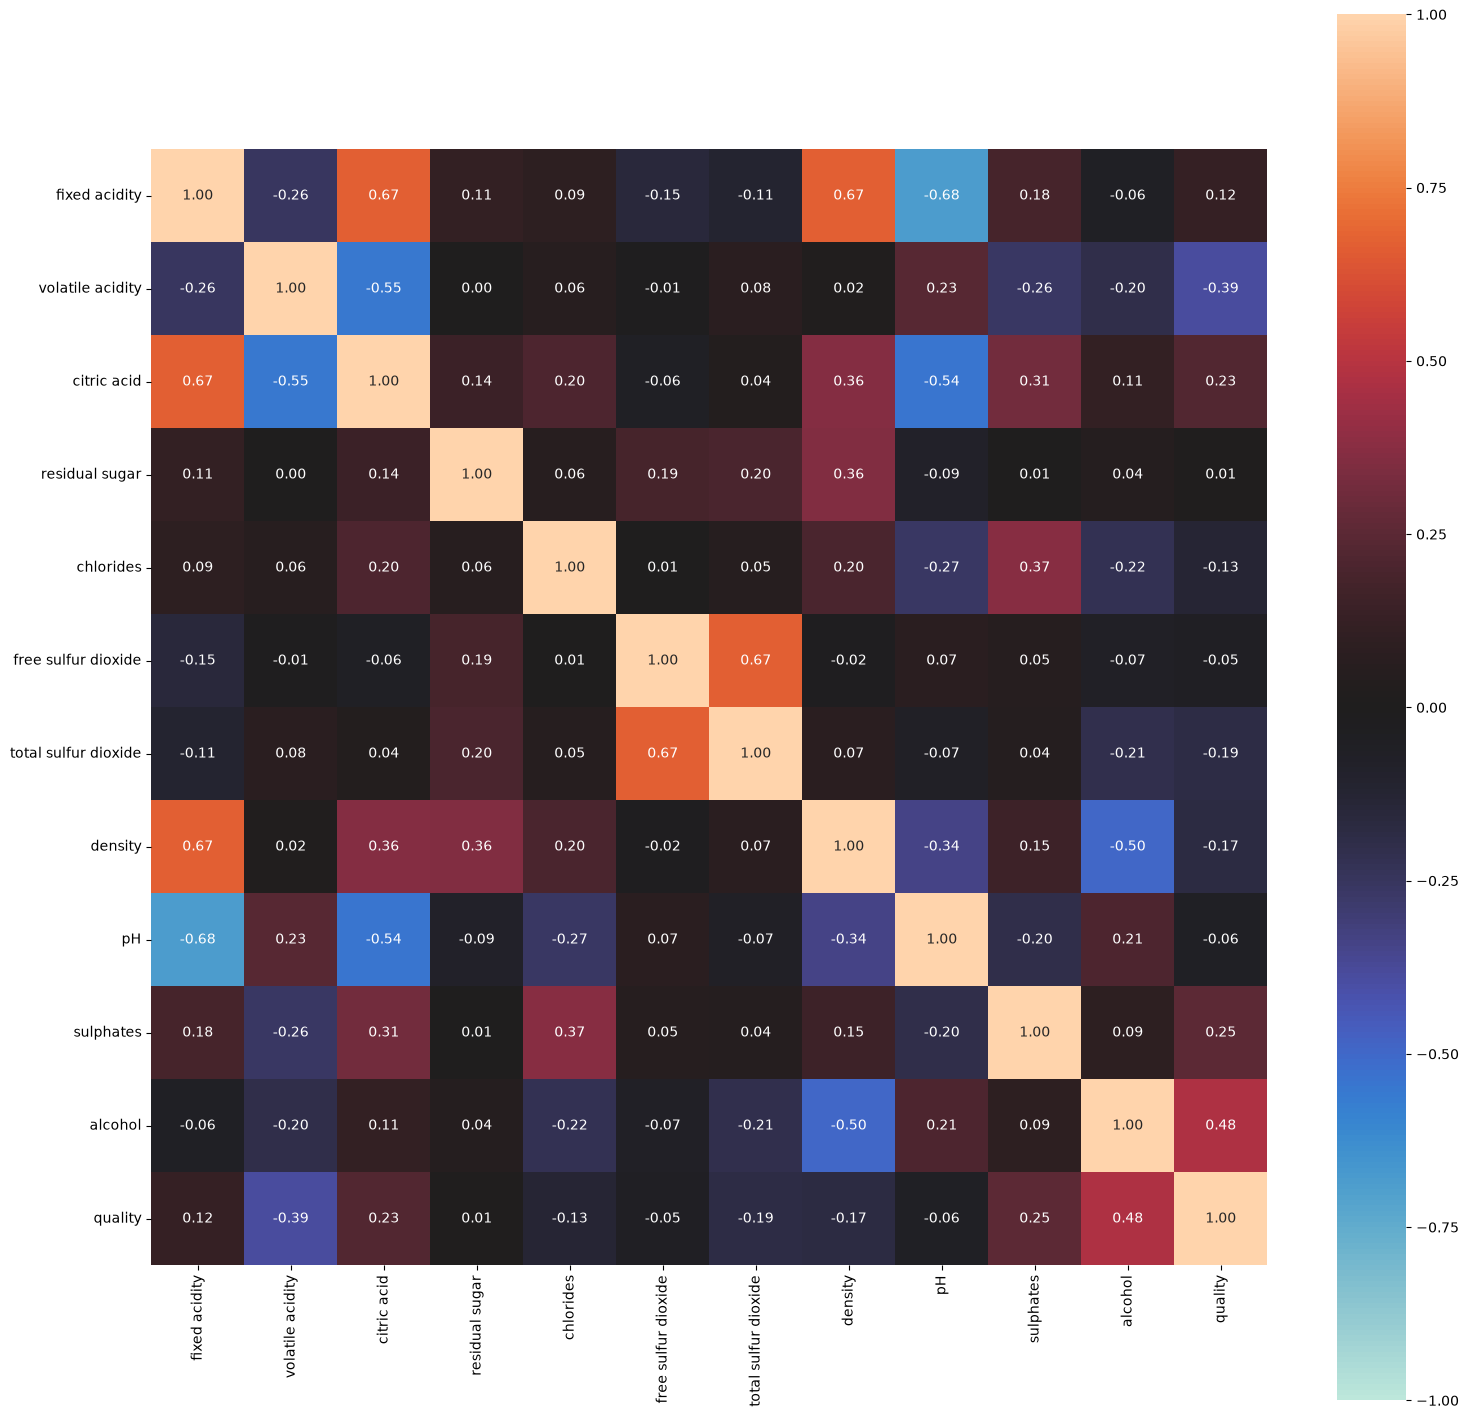

<hr>

##### <b> <u>Step 3e</u>: Feature importances</b> 

<i>
Which features seem to be the most important to your target variable?

<br>

How did you come to this conclusion? 
 
Should any of the variables be removed/dropped, or do they need further processing?

<br>

<u><b>Hint:</b></u> Correlation + PhiK matrices, SelectKBest, Fisher Score, RFE ...

</i>
<br>

<hr>

Fisher score

Total sulfur dioxide, volatile acidity and alcohol seem to be high here.

However, sulphates is low for some reason! 

Residual sugar is also marked as not so useful here.

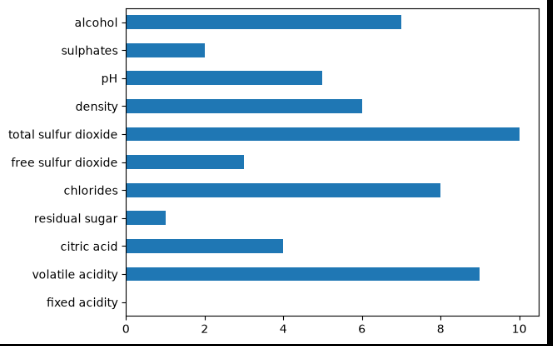

SelectKBest

Total sulfur dioxide is by far the most important variable here for some reason.

Chlorides, pH, density, sulphates and residual sugar are marked as not so useful.

Residual sugar seems repeating here now.

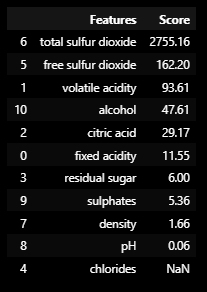

RFE

Volatile acidity and total sulfur dioxide are important here, also alcohol.

Residual sugar, fixed acidity, free sulfur dioxide and citric acid are not considered important here.

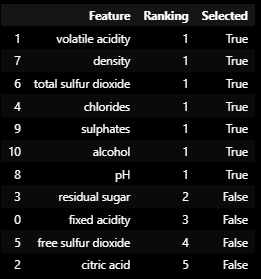

Mutual information:

Alcohol, sulphates and volatile acidity seem to be most imporatn here. Residual sugar and free sulfur dioxide are mentioned again as least important. 

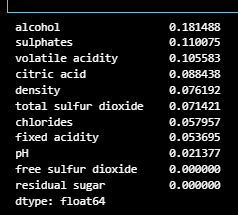

Summary:
- alcohol, volatile acidity, sulphates, total sulfur dioxide seem extremely important for target variable
- citric acid and chlorides might be important
- ph, residual sugar and free sulfur dioxide might be variables we want to remove later


<hr>

##### <b> <u>Step 3f</u>: Other potential problems or issues in the dataset? </b>

<i>
If you found anything else that is worth mentioning, and it isn’t found in the previous checklists, you can also elaborate on these for extra points.

<br>

This usually involves limitations in the datasets, weird behavior (e.g. doesn’t make sense from the common sense point of view) or something similar.



</i>

<hr>

Due to the amount of noise and overlap (and limited amount of data), this dataset is notorious for being difficult to solve in ML context. Accuracy scores 80-85% are pretty much the highest that have been done with a single model.

A wild idea for the future: attempt solving this with two models => Classification AND Regression.

The logic is this: if classification result is uncertain (low confidence), use regression instead. 

Other optimization methods include TomekLinks, clustering (KMeans or other variant), SMOTE and PCA, maybe others too.

---

### Summary of findings


<i> Please summarize all of the major findings and issues here briefly. A paragraph or two is fine. Lists are also OK.

</i>

- There's a very clear and serious overlap between the red wine quality, alcohol content and volatile acidity

    - The rough trend is, as quality goes up => alcohol goes and volatile acidity goes down... EXCEPT when we are in the average quality levels, when it can be either/or
    - Clustering, TomekLinks, PCA etc. or other optimization methods can be experimented with in order to differntiate between the average quality levels a bit more

- The dataset has mostly measurements in the variables, no categorical variables except the target variable itself
    - this means we'll mostly focus on outlier, noise, distribution management and other similar tools, common in regression datasets as well

- Most variables have a notable connection to target variable (quality), this might imply we might want to keep all original variables, at least in the beginning of optimization
    - some redundancy might be present, especially fixed acidity, free/total sulfur dioxide, maybe even residual sugar

---

##  Advanced tasks (optional, but extra points)

<br>
<br>

##### <b> <u>Step 4a</u>: Under-representation of combinatory categories</b> 

<i>
Are there any combinations of values which are exceptionally rare?

<br>

Example: A client for a bank might have a 18 year old customer with a 23 million Euro outstanding balance. 

Why are they rare? Do you expect these to be problematic? Could they be removed with minor repercussions?

<u><b>Hint:</b></u> Apriori

</i>

<br>
<br><br>

##### <b> <u>Step 4b</u>: Feature creation & derived features</b>

<i>
Can you combine features using operations (+, -, /, *) to make them more useful?

<br>

 Which features would you combine, how, and why?

Example: Credit lenders & debt / income ratio.
Example: Measurable speed – Km / hour

<br>

<u><b>Hint:</u></b> Sometimes, there just isn’t a clear combination of features that makes sense to add to your dataset. However, this problem is mitigated by other tools later in the course.


</i>

<br>
<br><br>

##### <b> <u>Step 4c</u>: Trends between features</b> 

<i>

What can you find when looking at the trends between the features of your dataset?
<br>

Are you noticing some interesting connections and trends?

Could there be some hidden value behind certain features that a machine learning model might find hard to see?
 
<br>

<u><b>Example:</b></u> House condition --> House quality -->  Price

<br>

Does any redundancy exist between these features?

Do you believe this trend would make a negative impact on your model?

Please show visuals of the most interesting feature-feature trends (scatterplot, regplot)

Which tool(s) did you use to inspect this?

<br>

<u><b>Hint:</b></u> You will find these especially (but are not limited to) in time-series data. Seaborn.regplots with hue are really useful here

<br>
<br><br>

</i>

##### <b><u>Step 4d</u>: Conventional EDA vs. tools </b>

<i>
Verify that the results in the tools are correct by using the conventional data-analytics skillset in Python. 

<br>

Use manual EDA (Exploratory Data Analysis), or in other words, <u>all the previous skills you have learnt in earlier data analytics studies.</u>

Verify with pandas features and seaborn visualizations and make sure the analysis of these tools are actually correct.

Are there any contradictions between the the new tools you've used and your own analysis?

<br><br>


##### <b> <u>Step 4e</u>: Non-linear connections / polynomial trends </b>

<i>
One of the features the evaluation tools have difficulties with is visualizing any non-linear connections in a dataset.

<br>

Seaborn, and its regression plot function, has a feature that supports polynomial regression as well.

For the most complicated pairs of variables, try using polynomial regression plots in your dataset and analyze the amount of noise, outliers and complexity your data might have.

</i>